In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../src")


from geodesiq import *

In [37]:
# ----- Define Hamiltonian and its gradient -----
def H_fun(x, z):
    return np.array([[z, x],
                     [x, -z]])

def H_partial(x, z):
    return np.array([[1, 0],
                     [0, -1]])

hamiltonian = Hamiltonian(H_fun, H_partial)

# ----- Set system and control parameters -----
alpha = 5
beta = 5
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf,
                        initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

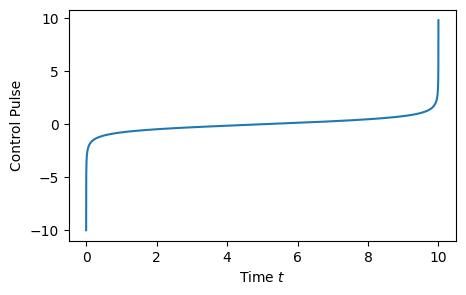

In [38]:
pulse = hamiltonian.synthesize_pulse(duration=10)
fig, ax = pulse.plot_pulse(show=True)


In [36]:
pulse = hamiltonian.synthesize_pulse(duration=10)
discretized_pulse = pulse.discretized_pulse()
discretized_pulse_direct = hamiltonian.synthesize_pulse(duration=10, method='discretized')
print(discretized_pulse)
print(discretized_pulse_direct)

(array([ 0.        ,  3.33333333,  6.66666667, 10.        ]), array([-10.        ,  -0.23207455,   0.23207163,   9.81761237]))
(array([ 0.        ,  3.33333333,  6.66666667, 10.        ]), array([-10.        ,  -0.23207455,   0.23207163,   9.81761237]))


In [42]:
pulse = hamiltonian.synthesize_pulse(duration=10)
filtered_pulse = pulse.filtered_pulse()
filtered_pulse_direct = hamiltonian.synthesize_pulse(duration=10, method='filtered')
print(filtered_pulse)
print(filtered_pulse_direct)

[-9.99981522 -9.86792408 -9.74353049 ...  9.58198522  9.6972972
  9.81689772]
[-9.99981522 -9.86792408 -9.74353049 ...  9.58198522  9.6972972
  9.81689772]


In [40]:
pulse = hamiltonian.synthesize_pulse(duration=10)
fourier = pulse.fourier_spectrum()
fourier_direct = hamiltonian.synthesize_pulse(duration=10, method='fourier')
print(fourier)
print(fourier_direct)

(array([0.000000e+00, 9.999990e-02, 1.999998e-01, ..., 4.999965e+04,
       4.999975e+04, 4.999985e+04], shape=(500000,)), array([1.45794102e+01, 2.67077121e+05, 1.77341906e+05, ...,
       9.97412976e+00, 9.97412976e+00, 9.97412976e+00], shape=(500000,)))
(array([0.000000e+00, 9.999990e-02, 1.999998e-01, ..., 4.999965e+04,
       4.999975e+04, 4.999985e+04], shape=(500000,)), array([1.45794102e+01, 2.67077121e+05, 1.77341906e+05, ...,
       9.97412976e+00, 9.97412976e+00, 9.97412976e+00], shape=(500000,)))
